<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/LLM_TimeSeries_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM Time Series Forecasting Lab
## 한국 전력수요 실데이터로 비교하는 SARIMA · Chronos · 소형 LLM

이 노트북은 **API Key 없이 Colab에서 직접 실행**하는 실습입니다.

### 비교할 모델
1. **Seasonal Naïve** — 가장 단순한 계절 기준선
2. **SARIMA** — 전통 통계 시계열 모형
3. **Chronos-T5-Tiny (8M)** — 시계열 Foundation Model, zero-shot forecasting
4. **Qwen2.5-0.5B-Instruct** — 범용 소형 LLM에 숫자를 프롬프트로 제공

### 핵심 질문
> 범용 LLM은 숫자 시계열 자체를 얼마나 잘 예측할 수 있는가?

**중요:** Qwen은 시계열 전용 모델이 아닙니다. 이 실습은 Qwen이 가장 잘 맞는다는 것을 보여주기 위한 것이 아니라,  
**전통모형·시계열 Foundation Model·범용 LLM의 역할 차이**를 직접 검증하기 위한 비교 실험입니다.

데이터: 한국전력거래소 전력통계정보시스템(EPSIS)에서 정리한 **2022–2025 월별 최대전력 평균(MW)**.

## 0. Colab 실행 환경

Colab 메뉴에서:

**런타임 → 런타임 유형 변경 → T4 GPU**

를 선택하는 것을 권장합니다.

**중요: 이 노트북은 반드시 위에서부터 순서대로 실행하세요.**  
Colab에서 런타임을 다시 시작하면 설치한 패키지가 사라지므로,
다시 접속했을 때는 **패키지 설치 셀부터 다시 실행**해야 합니다.

- Chronos-T5-Tiny: 약 **8M parameters**
- Qwen2.5-0.5B-Instruct: 약 **0.5B parameters**
- API 호출 없음
- Hugging Face에서 모델을 최초 1회 다운로드

공개 모델이므로 HF_TOKEN은 필수가 아닙니다.

In [1]:
# Colab 런타임에서 필요한 패키지를 설치합니다.
# %pip을 사용하면 현재 Jupyter/Colab Python 환경에 설치됩니다.

%pip install -q --upgrade "chronos-forecasting" "transformers>=4.37" accelerate statsmodels scikit-learn

# 설치 직후 import를 검증합니다.
import sys
import subprocess
import importlib.util

if importlib.util.find_spec("chronos") is None:
    print("PyPI 설치 후 chronos 모듈을 찾지 못했습니다.")
    print("Amazon 공식 GitHub 저장소에서 다시 설치합니다...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "git+https://github.com/amazon-science/chronos-forecasting.git"
    ])

from chronos import ChronosPipeline
import chronos

print("chronos import 성공")
print("chronos version:", getattr(chronos, "__version__", "unknown"))
print("chronos location:", chronos.__file__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 777.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.0 MB/s eta 0:00:00
chronos import 성공
chronos version: 2.3.2
chronos location: /usr/local/lib/python3.13/dist-packages/chronos/__init__.py


In [2]:
import warnings, json, re, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU가 없어도 실행은 가능하지만 Qwen 추론이 느릴 수 있습니다.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# Chronos API 확인
import inspect
from chronos import ChronosPipeline

print("ChronosPipeline.predict signature:")
print(inspect.signature(ChronosPipeline.predict))

ChronosPipeline.predict signature:
(self, inputs: Union[torch.Tensor, List[torch.Tensor]], prediction_length: Optional[int] = None, num_samples: Optional[int] = None, temperature: Optional[float] = None, top_k: Optional[int] = None, top_p: Optional[float] = None, limit_prediction_length: bool = False) -> torch.Tensor


### 참고: Hugging Face 경고 메시지

다음 메시지는 오류가 아닙니다.

- `unauthenticated requests to the HF Hub`  
  → 공개 모델은 로그인 없이도 다운로드할 수 있습니다.  
  HF_TOKEN은 다운로드 제한을 완화하고 속도를 높이고 싶을 때만 필요합니다.

- `torch_dtype is deprecated! Use dtype instead!`  
  → 이 수정본에서는 `dtype=`를 사용합니다.

Chronos 라이브러리는 버전에 따라 `predict()`의 첫 번째 인자 이름이 달라질 수 있으므로,
이 노트북은 `chronos.predict(context, prediction_length)`처럼 **위치 인자(positional arguments)** 를 사용합니다.

# 1. 한국 전력수요 데이터

2022–2025년 월별 최대전력 평균을 사용합니다.

- 학습구간: **2022-01 ~ 2024-12** (36개월)
- 테스트구간: **2025-01 ~ 2025-12** (12개월)
- Forecast horizon: **12개월**

따라서 모든 모델은 **2025년 실제값을 보지 않고 2025년 12개월을 예측**합니다.

In [4]:
# EPSIS 공개 통계에서 정리한 월별 최대전력 평균(MW)
values = [
    # 2022
    79797, 77278, 71145, 66096, 66243, 71805, 82007, 80375, 70674, 66443, 68926, 82176,
    # 2023
    79463, 76183, 68151, 64932, 65016, 70645, 79213, 82736, 73483, 65754, 71252, 76530,
    # 2024
    79136, 73263, 70091, 64455, 64361, 70480, 80515, 87799, 78052, 66907, 67831, 75537,
    # 2025
    75680, 77517, 68985, 65207, 64992, 71643, 85033, 85492, 77581, 66272, 68249, 76285
]

dates = pd.date_range("2022-01-01", periods=len(values), freq="MS")
df = pd.DataFrame({"date": dates, "demand_mw": values}).set_index("date")

display(df.head())
display(df.tail())
print("shape =", df.shape)

,demand_mw
date,
2022-01-01,79797
2022-02-01,77278
2022-03-01,71145
2022-04-01,66096
2022-05-01,66243


,demand_mw
date,
2025-08-01,85492
2025-09-01,77581
2025-10-01,66272
2025-11-01,68249
2025-12-01,76285


shape = (48, 1)


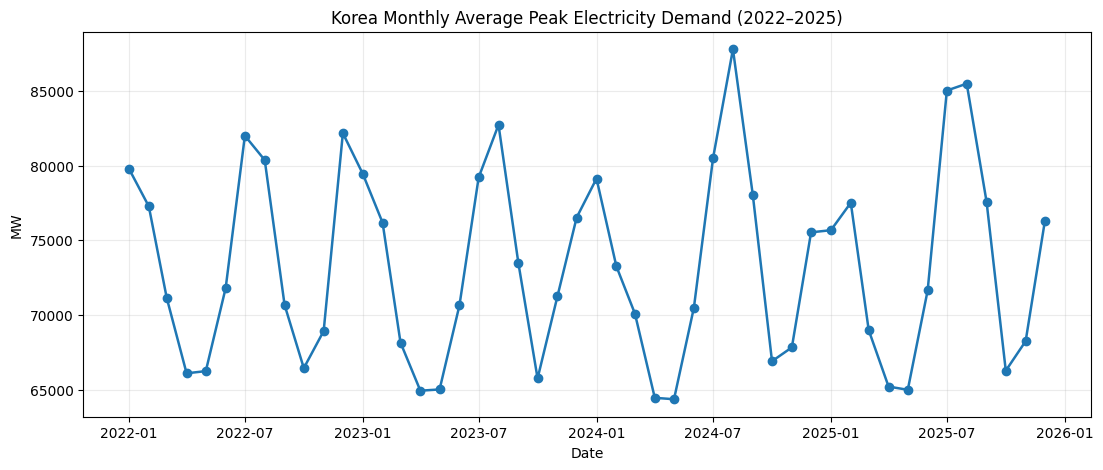

In [5]:
plt.figure(figsize=(13, 5))
plt.plot(df.index, df["demand_mw"], marker="o", linewidth=1.8)
plt.title("Korea Monthly Average Peak Electricity Demand (2022–2025)")
plt.ylabel("MW")
plt.xlabel("Date")
plt.grid(alpha=0.25)
plt.show()

### 무엇이 보이는가?

그래프를 보고 먼저 모델 없이 판단합니다.

- 여름철(7–8월) 피크가 반복되는가?
- 겨울철에도 상대적으로 높은 수요가 나타나는가?
- 같은 월이라도 연도별 수준은 같은가?
- 2024년 8월처럼 특별히 높은 값은 어떻게 처리해야 하는가?

> **좋은 시계열 분석은 모델 선택보다 먼저 데이터의 시간 구조를 관찰하는 것에서 시작합니다.**

In [6]:
train = df.loc[:"2024-12-01", "demand_mw"]
test  = df.loc["2025-01-01":, "demand_mw"]

H = len(test)

print("Train:", train.index.min().date(), "~", train.index.max().date(), "n =", len(train))
print("Test :", test.index.min().date(),  "~", test.index.max().date(),  "n =", len(test))

Train: 2022-01-01 ~ 2024-12-01 n = 36
Test : 2025-01-01 ~ 2025-12-01 n = 12


# 2. 평가 함수

모든 모델은 동일한 2025년 실제값과 비교합니다.

\[
MAE = \frac{1}{n}\sum |y_t-\hat y_t|
\]

\[
RMSE = \sqrt{\frac{1}{n}\sum(y_t-\hat y_t)^2}
\]

\[
MAPE = \frac{100}{n}\sum\left|\frac{y_t-\hat y_t}{y_t}\right|
\]

In [7]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE(%)": np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    }

results = {}
forecasts = {}

# 3. Baseline — Seasonal Naïve

월별 계절성이 강하므로 가장 간단한 기준선은:

> **2025년 1월 = 2024년 1월, 2025년 2월 = 2024년 2월, ...**

입니다.

복잡한 AI 모델이 이 기준선조차 이기지 못한다면 그 모델의 실용적 가치는 다시 검토해야 합니다.

In [8]:
seasonal_naive = train.iloc[-12:].to_numpy()
forecasts["Seasonal Naive"] = seasonal_naive
results["Seasonal Naive"] = metrics(test, seasonal_naive)

pd.DataFrame({
    "Actual_2025": test.values,
    "Seasonal_Naive": seasonal_naive
}, index=test.index)

,Actual_2025,Seasonal_Naive
date,,
2025-01-01,75680,79136
2025-02-01,77517,73263
2025-03-01,68985,70091
2025-04-01,65207,64455
2025-05-01,64992,64361
2025-06-01,71643,70480
2025-07-01,85033,80515
2025-08-01,85492,87799
2025-09-01,77581,78052


# 4. SARIMA — 전통 통계 시계열 모형

월별 계절주기 `s=12`를 반영합니다.

이 데이터는 학습표본이 36개월로 매우 짧기 때문에 복잡한 차수 탐색보다  
교육용으로 비교적 단순한 SARIMA 구조를 사용합니다.

In [9]:
sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit(disp=False)
sarima_pred = sarima_fit.forecast(H).to_numpy()

forecasts["SARIMA"] = sarima_pred
results["SARIMA"] = metrics(test, sarima_pred)

print(sarima_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


                                     SARIMAX Results                                      
Dep. Variable:                          demand_mw   No. Observations:                   36
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -83.742
Date:                            Wed, 16 Sep 2026   AIC                            175.484
Time:                                    13:58:33   BIC                            176.273
Sample:                                01-01-2022   HQIC                           173.781
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1374      8.979     -0.015      0.988     -17.735      17.460
ma.L1          0.1898      8.930   

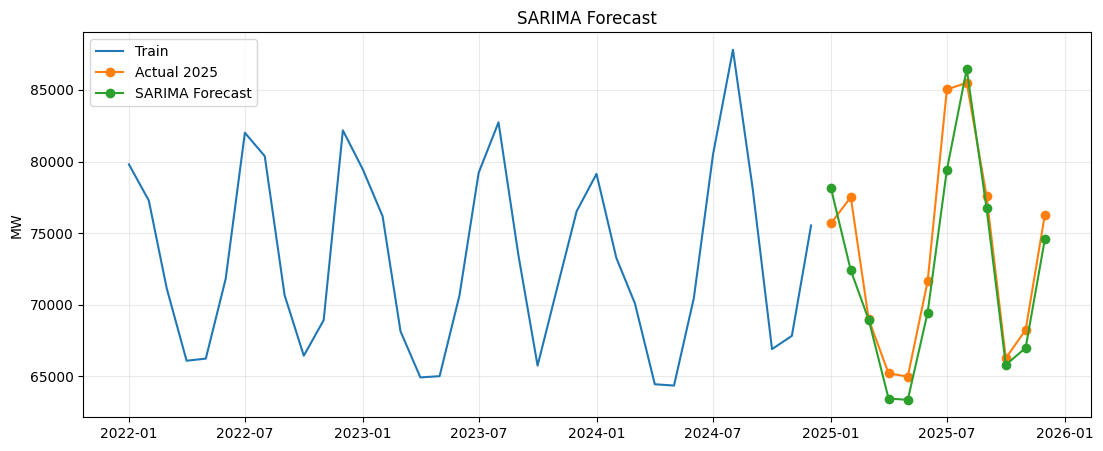

In [10]:
plt.figure(figsize=(13, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, marker="o", label="Actual 2025")
plt.plot(test.index, sarima_pred, marker="o", label="SARIMA Forecast")
plt.title("SARIMA Forecast")
plt.ylabel("MW")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 5. Chronos-T5-Tiny — Time-Series Foundation Model

Amazon의 Chronos는 시계열을 토큰화한 뒤 Transformer 계열 모델로 학습한  
**Time-Series Foundation Model**입니다.

여기서는 **`amazon/chronos-t5-tiny` (8M parameters)**를 사용합니다.

핵심 차이:

- SARIMA: 현재 데이터에 직접 모형을 **적합(fit)**
- Chronos: 대규모 사전학습 모델을 새 데이터에 **zero-shot** 적용

In [11]:
from chronos import ChronosPipeline
import inspect

device_map = "cuda" if torch.cuda.is_available() else "cpu"

# Public model: HF_TOKEN is optional.
# dtype is used instead of the deprecated transformers torch_dtype keyword.
chronos = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map=device_map,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

context = torch.tensor(train.values, dtype=torch.float32)

print("Chronos predict signature:")
print(inspect.signature(chronos.predict))

# Chronos package versions have used slightly different parameter names.
# Passing the first two arguments positionally is the most version-tolerant form.
try:
    chronos_samples = chronos.predict(
        context,
        H,
        num_samples=100
    )
except TypeError as e:
    print("num_samples option is not supported by this installed version.")
    print("Retrying with the minimal positional API...")
    chronos_samples = chronos.predict(context, H)

# Expected original Chronos-T5 output:
# [num_series, num_samples, prediction_length]
if isinstance(chronos_samples, torch.Tensor):
    forecast_tensor = chronos_samples.detach().float().cpu()
else:
    forecast_tensor = torch.as_tensor(chronos_samples).float().cpu()

print("Forecast tensor shape:", tuple(forecast_tensor.shape))

if forecast_tensor.ndim == 3:
    # First series -> [num_samples, horizon]
    chronos_np = forecast_tensor[0].numpy()
    chronos_pred = np.median(chronos_np, axis=0)
elif forecast_tensor.ndim == 2:
    # Some pipeline variants may directly return [num_series, horizon]
    chronos_pred = forecast_tensor[0].numpy()
    chronos_np = chronos_pred[None, :]
else:
    raise ValueError(
        f"Unexpected Chronos output shape: {tuple(forecast_tensor.shape)}"
    )

forecasts["Chronos-Tiny"] = chronos_pred
results["Chronos-Tiny"] = metrics(test, chronos_pred)

print("Chronos forecast:", np.round(chronos_pred, 1))

config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 33.6MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos predict signature:
(inputs: Union[torch.Tensor, List[torch.Tensor]], prediction_length: Optional[int] = None, num_samples: Optional[int] = None, temperature: Optional[float] = None, top_k: Optional[int] = None, top_p: Optional[float] = None, limit_prediction_length: bool = False) -> torch.Tensor
Forecast tensor shape: (1, 100, 12)
Chronos forecast: [79948.2 77802.  74046.  69216.9 65461.  67070.7 72436.3 80484.8 85045.6
 76192.3 69216.9 71899.7]


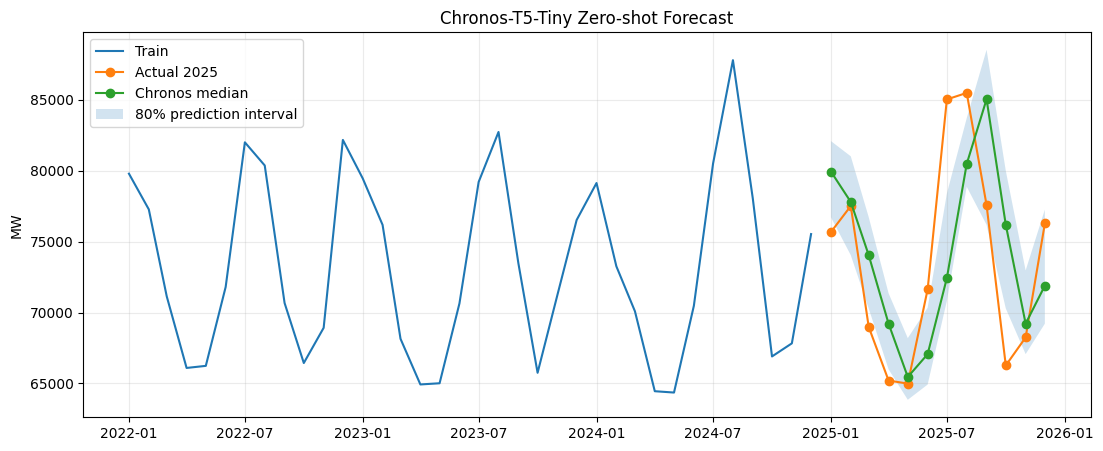

In [12]:
# Prediction interval can only be estimated when multiple forecast samples exist.
if chronos_np.shape[0] > 1:
    lower = np.quantile(chronos_np, 0.1, axis=0)
    upper = np.quantile(chronos_np, 0.9, axis=0)
else:
    lower = upper = None

plt.figure(figsize=(13, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, marker="o", label="Actual 2025")
plt.plot(test.index, chronos_pred, marker="o", label="Chronos median")

if lower is not None:
    plt.fill_between(
        test.index, lower, upper,
        alpha=0.2, label="80% prediction interval"
    )

plt.title("Chronos-T5-Tiny Zero-shot Forecast")
plt.ylabel("MW")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 6. 범용 소형 LLM — Qwen2.5-0.5B-Instruct

이제 **범용 언어모델**에 숫자 시계열을 텍스트로 보여주고 같은 12개월을 예측시킵니다.

### 중요한 점
Qwen2.5-0.5B-Instruct는 **시계열 전용 모델이 아닙니다.**

즉 이 실험의 질문은:

> “범용 LLM이 텍스트로 표현된 숫자 패턴을 보고 어느 정도 계절 구조를 추론할 수 있는가?”

입니다.

API는 사용하지 않습니다. 모델을 Colab GPU 메모리에 직접 올립니다.

In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM

LLM_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)

llm = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    torch_dtype="auto",
    device_map="auto"
)

print("Loaded:", LLM_NAME)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-0.5B-Instruct


## LLM에게 보낼 프롬프트

2022–2024년 36개월 값을 다음과 같이 텍스트로 제공합니다.

LLM에는 2025년 실제값을 제공하지 않습니다.

출력 형식은 파싱이 쉽도록 JSON으로 강제합니다.

In [14]:
def make_llm_prompt(series):
    rows = []
    for dt, val in series.items():
        rows.append(f"{dt.strftime('%Y-%m')}: {int(val)}")
    history = "\n".join(rows)

    prompt = f'''
You are forecasting monthly electricity peak demand in Korea.

Below are 36 monthly observations in MW from January 2022 through December 2024.

{history}

Task:
Predict the next 12 monthly values for January 2025 through December 2025.

Instructions:
- Pay attention to annual seasonality.
- Summer months often show high demand.
- Winter months may also have relatively high demand.
- Return exactly 12 numeric forecasts.
- Do not include explanations.
- Output valid JSON only in this exact structure:

{{"forecasts": [v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11, v12]}}
'''
    return prompt.strip()

llm_prompt = make_llm_prompt(train)
print(llm_prompt)

You are forecasting monthly electricity peak demand in Korea.

Below are 36 monthly observations in MW from January 2022 through December 2024.

2022-01: 79797
2022-02: 77278
2022-03: 71145
2022-04: 66096
2022-05: 66243
2022-06: 71805
2022-07: 82007
2022-08: 80375
2022-09: 70674
2022-10: 66443
2022-11: 68926
2022-12: 82176
2023-01: 79463
2023-02: 76183
2023-03: 68151
2023-04: 64932
2023-05: 65016
2023-06: 70645
2023-07: 79213
2023-08: 82736
2023-09: 73483
2023-10: 65754
2023-11: 71252
2023-12: 76530
2024-01: 79136
2024-02: 73263
2024-03: 70091
2024-04: 64455
2024-05: 64361
2024-06: 70480
2024-07: 80515
2024-08: 87799
2024-09: 78052
2024-10: 66907
2024-11: 67831
2024-12: 75537

Task:
Predict the next 12 monthly values for January 2025 through December 2025.

Instructions:
- Pay attention to annual seasonality.
- Summer months often show high demand.
- Winter months may also have relatively high demand.
- Return exactly 12 numeric forecasts.
- Do not include explanations.
- Output valid 

In [15]:
messages = [
    {
        "role": "system",
        "content": "You are a numerical forecasting assistant. Follow the output format exactly."
    },
    {
        "role": "user",
        "content": llm_prompt
    }
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer([text], return_tensors="pt").to(llm.device)

with torch.no_grad():
    output_ids = llm.generate(
        **inputs,
        max_new_tokens=220,
        do_sample=False,
        repetition_penalty=1.05
    )

generated_ids = output_ids[:, inputs.input_ids.shape[1]:]
llm_text = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(llm_text)

{
  "forecasts": [79136, 73263, 70091, 64455, 64361, 70480, 80515, 87799, 78052, 66907, 67831, 75537]
}


In [16]:
def parse_12_forecasts(text):
    # 1) JSON 우선
    try:
        obj = json.loads(text.strip())
        vals = obj["forecasts"]
        vals = [float(v) for v in vals]
        if len(vals) == 12:
            return np.array(vals, dtype=float)
    except Exception:
        pass

    # 2) JSON 블록 탐색
    m = re.search(r'\{.*?\}', text, flags=re.S)
    if m:
        try:
            obj = json.loads(m.group())
            vals = [float(v) for v in obj["forecasts"]]
            if len(vals) == 12:
                return np.array(vals, dtype=float)
        except Exception:
            pass

    # 3) forecasts 배열 안의 숫자 추출
    m = re.search(r'forecasts\s*["\']?\s*:\s*\[(.*?)\]', text, flags=re.S|re.I)
    if m:
        nums = re.findall(r'-?\d+(?:\.\d+)?', m.group(1))
        vals = [float(x) for x in nums]
        if len(vals) >= 12:
            return np.array(vals[:12], dtype=float)

    raise ValueError(
        "12개 예측값을 파싱하지 못했습니다. "
        "Qwen 출력이 형식을 지키지 않은 경우 해당 셀을 한 번 더 실행해 보세요."
    )

qwen_pred = parse_12_forecasts(llm_text)

forecasts["Qwen-0.5B"] = qwen_pred
results["Qwen-0.5B"] = metrics(test, qwen_pred)

print("Qwen forecast:", qwen_pred)

Qwen forecast: [79136. 73263. 70091. 64455. 64361. 70480. 80515. 87799. 78052. 66907.
 67831. 75537.]


# 7. 모든 모델을 동일 조건에서 비교

이제 실제 2025년 값과 네 가지 모델을 한 번에 비교합니다.

In [17]:
result_df = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE")
)

display(result_df.round(3))

,MAE,RMSE,MAPE(%)
Seasonal Naive,1704.917,2248.588,2.215
Qwen-0.5B,1704.917,2248.588,2.215
SARIMA,2001.631,2591.864,2.644
Chronos-Tiny,4917.279,6049.561,6.585


,Actual,Seasonal Naive,SARIMA,Chronos-Tiny,Qwen-0.5B
date,,,,,
2025-01-01,75680,79136,78134.8,79948.203125,79136.0
2025-02-01,77517,73263,72403.5,77802.000000,73263.0
2025-03-01,68985,70091,68950.5,74046.000000,70091.0
2025-04-01,65207,64455,63453.4,69216.898438,64455.0
2025-05-01,64992,64361,63370.3,65461.000000,64361.0
2025-06-01,71643,70480,69458.6,67070.703125,70480.0
2025-07-01,85033,80515,79409.8,72436.296875,80515.0
2025-08-01,85492,87799,86450.2,80484.796875,87799.0
2025-09-01,77581,78052,76732.9,85045.601562,78052.0


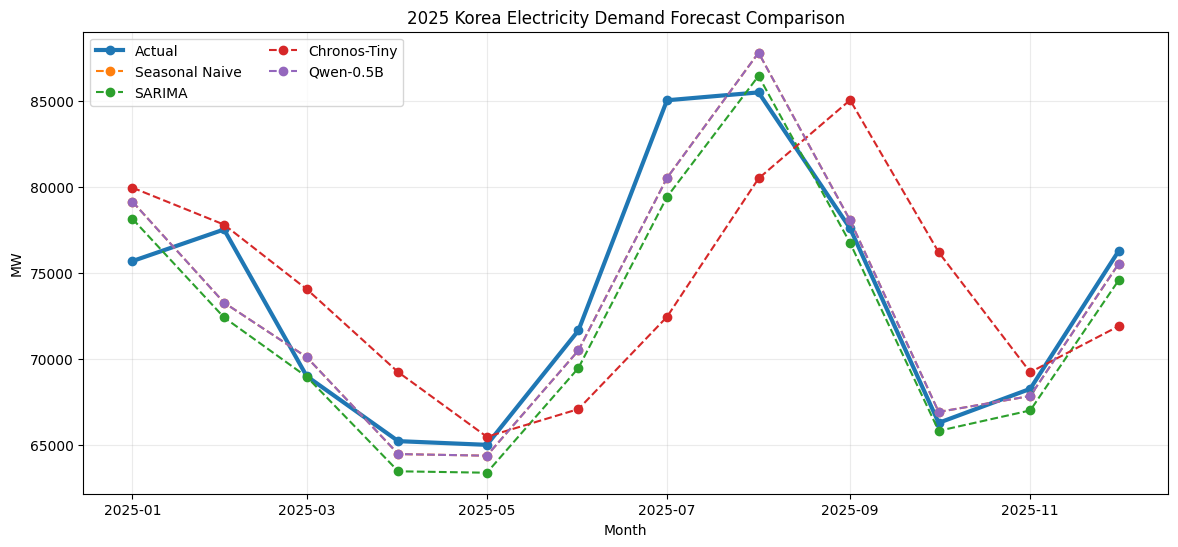

In [18]:
compare = pd.DataFrame(
    {"Actual": test.values, **forecasts},
    index=test.index
)

display(compare.round(1))

plt.figure(figsize=(14, 6))
plt.plot(compare.index, compare["Actual"], marker="o", linewidth=3, label="Actual")

for col in compare.columns[1:]:
    plt.plot(compare.index, compare[col], marker="o", linestyle="--", label=col)

plt.title("2025 Korea Electricity Demand Forecast Comparison")
plt.ylabel("MW")
plt.xlabel("Month")
plt.legend(ncol=2)
plt.grid(alpha=0.25)
plt.show()

# 8. 결과를 어떻게 해석할 것인가?

단순히 **“누가 1등인가?”**만 보지 않습니다.

| 접근 | 무엇을 학습하는가 | 이 실습에서 볼 점 |
|---|---|---|
| Seasonal Naïve | 작년 동일월 반복 | 강력한 최소 기준선 |
| SARIMA | 현재 시계열의 통계적 구조 | 추세·계절성의 명시적 모형화 |
| Chronos | 대규모 시계열 사전학습 | zero-shot 일반화 |
| Qwen 0.5B | 범용 텍스트/언어 패턴 | 숫자 패턴을 텍스트 토큰으로 처리 |

### 토론
1. 가장 복잡한 모델이 항상 가장 정확했는가?
2. Chronos가 별도 학습 없이 예측할 수 있다는 것은 무엇을 의미하는가?
3. 범용 LLM이 계절성을 어느 정도 재현했는가?
4. Qwen 결과가 좋더라도 그것을 안정적인 numerical forecaster라고 볼 수 있는가?
5. 긴 시계열에서는 LLM의 tokenization과 context length가 어떤 문제가 될까?

# 9. 선택 실습 — Prompt Sensitivity

같은 Qwen 모델이라도 프롬프트를 바꾸면 결과가 달라지는지 확인해 봅니다.

### Prompt A
숫자만 보고 다음 12개 값을 예측

### Prompt B
연간 계절성을 고려하라고 명시

### Prompt C
“한국 전력수요 전문가” 역할 + 여름/겨울 수요 특성 제공

이 비교는 **Prompt Sensitivity**와 **재현성**을 설명하는 좋은 실습입니다.

아래 함수에서 `instruction` 문구를 바꿔 반복 실행해 보세요.

In [19]:
def qwen_forecast_with_instruction(train_series, instruction):
    rows = [f"{dt.strftime('%Y-%m')}: {int(val)}" for dt, val in train_series.items()]
    history = "\n".join(rows)

    user_prompt = f'''
Historical monthly series in MW:
{history}

{instruction}

Predict the next 12 months.
Return JSON only:
{{"forecasts": [12 numeric values]}}
'''.strip()

    messages = [
        {"role": "system", "content": "Return numerical forecasts in valid JSON only."},
        {"role": "user", "content": user_prompt}
    ]

    txt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([txt], return_tensors="pt").to(llm.device)

    with torch.no_grad():
        out = llm.generate(
            **inputs,
            max_new_tokens=220,
            do_sample=False
        )

    answer = tokenizer.batch_decode(
        out[:, inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )[0]

    return answer, parse_12_forecasts(answer)

# 예:
# answer_A, pred_A = qwen_forecast_with_instruction(
#     train,
#     "Forecast from the numerical pattern only."
# )
# print(answer_A)

# 10. 연구 확장

이 실습을 연구 수준으로 확장하려면 다음이 필요합니다.

- 월별 48개보다 훨씬 긴 데이터 사용
- rolling / expanding window 평가
- 여러 forecast origin에서 반복 실험
- LLM prompt별 반복실험과 변동성 측정
- Diebold–Mariano test
- 기온·습도·휴일 등 외생변수 추가
- General LLM vs Time-Series Foundation Model 구분
- 비용·속도·재현성·설명가능성까지 비교

### 핵심 메시지

> **LLM은 ARIMA를 대체하는 하나의 “더 좋은 모형”이라기보다,  
> 시계열과 텍스트·추론·외부정보를 연결할 수 있는 새로운 분석 구성요소로 보는 것이 적절하다.**

---
### 데이터 출처
- 한국전력거래소 전력통계정보시스템(EPSIS): 월별 최대전력 평균
- https://epsis.kpx.or.kr/

### 모델
- Amazon Chronos-T5-Tiny: https://huggingface.co/amazon/chronos-t5-tiny
- Qwen2.5-0.5B-Instruct: https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct

본 노트북의 Qwen 실습은 **범용 LLM의 시계열 예측 능력을 검증하기 위한 교육용 비교 실험**입니다.